# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [174]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [175]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [176]:
# ============================================================
# TASK 9
# Anchor-Free Object Detection (YOLOv8 Style)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [177]:
#Dummy Detection Dataset
batch_size = 8

images = torch.randn(batch_size,3,256,256).to(device)

# bbox = [x,y,w,h] normalized

target_boxes = torch.rand(batch_size,4).to(device)

target_classes = torch.randint(0,2,(batch_size,1)).float().to(device)

target_object = torch.ones(batch_size,1).to(device)

In [178]:
#Tiny Backbone
class TinyBackbone(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)

        )

    def forward(self,x):

        x=self.features(x)

        return torch.flatten(x,1)

In [179]:
#Detection Head
class DetectionHead(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = TinyBackbone()

        self.box = nn.Linear(128,4)

        self.cls = nn.Linear(128,1)

        self.obj = nn.Linear(128,1)

    def forward(self,x):

        x=self.backbone(x)

        box=torch.sigmoid(self.box(x))

        cls=self.cls(x)

        obj=self.obj(x)

        return box,cls,obj

In [180]:
#Complete IoU (CIoU) Loss
class CIoULoss(nn.Module):

    def forward(self,pred,target):

        px,py,pw,ph = pred.unbind(-1)

        tx,ty,tw,th = target.unbind(-1)

        p_x1 = px-pw/2
        p_y1 = py-ph/2
        p_x2 = px+pw/2
        p_y2 = py+ph/2

        t_x1 = tx-tw/2
        t_y1 = ty-th/2
        t_x2 = tx+tw/2
        t_y2 = ty+th/2

        inter_x1=torch.max(p_x1,t_x1)
        inter_y1=torch.max(p_y1,t_y1)
        inter_x2=torch.min(p_x2,t_x2)
        inter_y2=torch.min(p_y2,t_y2)

        inter=(inter_x2-inter_x1).clamp(0)*(inter_y2-inter_y1).clamp(0)

        area1=(p_x2-p_x1)*(p_y2-p_y1)
        area2=(t_x2-t_x1)*(t_y2-t_y1)

        union=area1+area2-inter+1e-7

        iou=inter/union

        center=((px-tx)**2+(py-ty)**2)

        cx1=torch.min(p_x1,t_x1)
        cy1=torch.min(p_y1,t_y1)
        cx2=torch.max(p_x2,t_x2)
        cy2=torch.max(p_y2,t_y2)

        diagonal=((cx2-cx1)**2+(cy2-cy1)**2)+1e-7

        loss=1-(iou-center/diagonal)

        return loss.mean()

In [181]:
#YOLO Loss
class YOLOLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.box_loss = CIoULoss()

        self.cls_loss = nn.BCEWithLogitsLoss()

        self.obj_loss = nn.BCEWithLogitsLoss()

    def forward(self,

                pred_box,
                pred_cls,
                pred_obj,

                target_box,
                target_cls,
                target_obj):

        box=self.box_loss(
            pred_box,
            target_box
        )

        cls=self.cls_loss(
            pred_cls,
            target_cls
        )

        obj=self.obj_loss(
            pred_obj,
            target_obj
        )

        total=5*box+cls+obj

        return total,box,cls,obj

In [182]:
#Model
model = DetectionHead().to(device)

criterion = YOLOLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [183]:
#Training
losses=[]

epochs=30

for epoch in range(epochs):

    optimizer.zero_grad()

    box,cls,obj=model(images)

    total,box_loss,cls_loss,obj_loss=criterion(

        box,
        cls,
        obj,

        target_boxes,
        target_classes,
        target_object

    )

    total.backward()

    optimizer.step()

    losses.append(total.item())

    print(
        f"Epoch {epoch+1:02d}"
        f" | Total {total:.4f}"
        f" | Box {box_loss:.4f}"
        f" | Cls {cls_loss:.4f}"
        f" | Obj {obj_loss:.4f}"
    )

Epoch 01 | Total 6.4832 | Box 1.0407 | Cls 0.6843 | Obj 0.5953
Epoch 02 | Total 6.3524 | Box 1.0230 | Cls 0.6679 | Obj 0.5693
Epoch 03 | Total 6.2269 | Box 1.0060 | Cls 0.6523 | Obj 0.5446
Epoch 04 | Total 6.1018 | Box 0.9886 | Cls 0.6376 | Obj 0.5211
Epoch 05 | Total 5.9752 | Box 0.9706 | Cls 0.6237 | Obj 0.4986
Epoch 06 | Total 5.8404 | Box 0.9505 | Cls 0.6105 | Obj 0.4772
Epoch 07 | Total 5.7123 | Box 0.9315 | Cls 0.5981 | Obj 0.4566
Epoch 08 | Total 5.5867 | Box 0.9127 | Cls 0.5863 | Obj 0.4367
Epoch 09 | Total 5.4820 | Box 0.8978 | Cls 0.5752 | Obj 0.4176
Epoch 10 | Total 5.3704 | Box 0.8813 | Cls 0.5647 | Obj 0.3992
Epoch 11 | Total 5.2565 | Box 0.8640 | Cls 0.5548 | Obj 0.3816
Epoch 12 | Total 5.1380 | Box 0.8455 | Cls 0.5456 | Obj 0.3647
Epoch 13 | Total 5.0193 | Box 0.8268 | Cls 0.5369 | Obj 0.3486
Epoch 14 | Total 4.9080 | Box 0.8092 | Cls 0.5288 | Obj 0.3331
Epoch 15 | Total 4.8050 | Box 0.7931 | Cls 0.5213 | Obj 0.3184
Epoch 16 | Total 4.7342 | Box 0.7831 | Cls 0.5144 | Obj

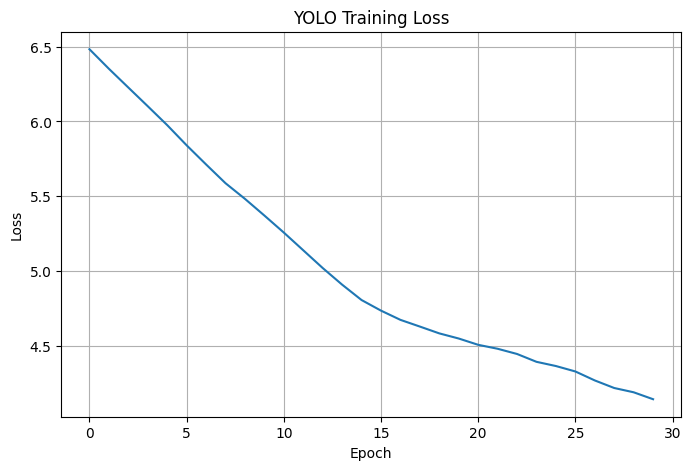

In [184]:
#Loss Curve
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("YOLO Training Loss")

plt.grid(True)

plt.show()

In [185]:
#Predictions
model.eval()

with torch.no_grad():

    box,cls,obj=model(images)

print("Bounding Boxes")

print(box[:5])

print()

print("Class Scores")

print(torch.sigmoid(cls[:5]))

print()

print("Objectness Scores")

print(torch.sigmoid(obj[:5]))

Bounding Boxes
tensor([[0.0371, 0.9977, 0.2107, 0.9322],
        [0.0665, 0.9999, 0.2305, 0.9794],
        [0.0400, 0.9999, 0.1908, 0.9756],
        [0.0471, 1.0000, 0.1896, 0.9848],
        [0.0362, 0.9997, 0.1849, 0.9679]], device='cuda:0')

Class Scores
tensor([[0.0396],
        [0.0678],
        [0.0351],
        [0.0397],
        [0.0344]], device='cuda:0')

Objectness Scores
tensor([[0.9639],
        [0.9910],
        [0.9883],
        [0.9927],
        [0.9843]], device='cuda:0')
